In [21]:
%pip install wandb

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [23]:
import wandb
wandb.login()

wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.
wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize
wandb: Paste an API key from your profile and hit enter:wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /home/sangheon/.netrc
wandb: Currently logged in as: michpark (michpark-georgia-institute-of-technology) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [ ]:
wandb.init{
    project =
}

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import librosa
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import os
from torch.utils.data import Dataset, DataLoader
import seaborn as sns
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import random
import csv
import json
from tqdm import tqdm
from joblib import Parallel, delayed
import IPython.display as ipd

In [11]:
class CNNChromagram(nn.Module):
    def __init__(self, input_time=861):
        super(CNNChromagram, self).__init__()

        self.conv1 = nn.Conv2d(1, 32, kernel_size=(3, 3), padding='same', dilation=(1, 2))
        self.conv2 = nn.Conv2d(32, 64, kernel_size=(3, 3), padding='same', dilation=(1, 2))
        self.conv3 = nn.Conv2d(64, 128, kernel_size=(3, 3), padding='same', dilation=(1, 2))

        self.bn1 = nn.BatchNorm2d(32)
        self.bn2 = nn.BatchNorm2d(64)
        self.bn3 = nn.BatchNorm2d(128)

        fc_input_size = 64 * (25 // 4)

        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(kernel_size=(2, 1))

        self.lstm = nn.LSTM(input_size=fc_input_size, hidden_size=128,
                            num_layers=1, batch_first=True, bidirectional=True)

        fc_input_size = 64 * (25 // 4)

        #self.fc1 = nn.Linear(fc_input_size, 64)
        self.fc1 = nn.Linear(128 * 2, 64)
        self.fc2 = nn.Linear(64, 5)

        self.dropout = nn.Dropout(0.3)

    def forward(self, x):
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.pool(x)

        x = self.relu(self.bn2(self.conv2(x)))
        x = self.pool(x)

        x = self.relu(self.bn3(self.conv3(x)))
        x = self.pool(x)

        batch_size, channels, freq_bins, time_steps = x.shape

        x = x.permute(0, 3, 1, 2)
        x = x.reshape(batch_size, time_steps, -1)
        x, _ = self.lstm(x)
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)

        return x

In [17]:
class ChromaDataset(Dataset):
    def __init__(self, audio_dir, label_json, num_classes=5, sr=16000, window_size=20, hop_length=512, target_bins=25):
        super().__init__()
        self.sr = sr
        self.target_bins = target_bins
        self.audio_files = [f for f in os.listdir(audio_dir) if f.endswith('.wav') or f.endswith('.mp3')]
        self.loaded_audio = self.get_audio(audio_dir)
        self.loaded_chromas = self.get_chroma()
        self.df = self.get_df(label_json)
        self.window_size = window_size
        self.window_frames = window_size*sr//hop_length
        self.num_classes = num_classes
        self.label_map = {"Unknown":0, "창조":0, "설렁제":0, "경드름": 0, "우조": 1, "계면조": 2, "평조": 3, "아니리": 4}
        self.hop_length = hop_length

    def get_audio(self, audio_dir):
        '''
        오디오 파일을 load 후 Dictionary {filename: waveform} 형태로 저장
        '''
        loaded_audio = {}
        for filename in tqdm(self.audio_files, desc='Load Audio'):
            y, _ = librosa.load(os.path.join(audio_dir, filename), sr=self.sr)
            loaded_audio[filename] = y
        return loaded_audio

    def get_chroma(self):
        '''
        loaded_audio를 로드하여 file별로 chromagram 생성 후 target bins에 맞추어 expand하여 반환
        '''
        chroma_dict = {}
        for filename, audio_key_value in zip(tqdm(self.audio_files, desc="Load Chroma"), self.loaded_audio.items()):
            chroma = librosa.feature.chroma_stft(y=audio_key_value[1], sr=self.sr)
            repeat = self.target_bins // chroma.shape[0] + 1
            expanded_chroma = np.tile(chroma, (repeat, 1))
            chroma_dict[filename]=expanded_chroma[:self.target_bins, :]
        return chroma_dict

    def get_df(self, label_json):
        with open(label_json, "r", encoding="utf-8") as file: label_data = json.load(file)
        df = pd.DataFrame(columns=['filename', 'start', 'end', 'duration', 'label'])
        row = 0

        # 노래 파일 마다 레이블 정보 저장
        song_segments = {}
        for song in label_data:
            filename = song['file_upload'][:-3]+'wav'
            if filename not in song_segments: song_segments[filename] = []

            for val in song['annotations'][0]["result"]:
                start = val['value']['start']
                end = val['value']['end']
                label = val['value']['labels'][0]
                song_segments[filename].append((start, end, label))

        for filename, segments in song_segments.items():
            prev_end = None
            segments.sort(key=lambda x: x[0])
            for start, end, label in segments:
                if prev_end is not None and int(prev_end) != int(start):
                    gap_start, gap_end = prev_end+1e-6, start-1e-6
                    gap_duration = gap_end - gap_start

                    if gap_duration < 1: continue
                    df.loc[row] = [filename, gap_start, gap_end, gap_duration, "Unknown"]
                    row += 1

                duration = end - start
                df.loc[row] = [filename, start, end, duration, label]
                prev_end = end
                row += 1
        return df

    def get_label_for_segment(self, filename, start_frame, end_frame):
        segment_labels = np.zeros((self.window_frames, self.num_classes))
        segment_labels[:, self.label_map["Unknown"]] = 1

        file_df = self.df[self.df['filename'] == filename]

        if not file_df.empty:
            for _, row in file_df.iterrows():
                label_start_frame = int((row['start'] / self.hop_length) * self.sr)
                label_end_frame = int((row['end'] / self.hop_length) * self.sr)

                overlap_start = max(start_frame, label_start_frame)
                overlap_end = min(end_frame, label_end_frame)

                if overlap_start < overlap_end:
                    segment_start_idx = int(overlap_start - start_frame)
                    segment_end_idx = int(overlap_end - start_frame)

                    segment_labels[segment_start_idx:segment_end_idx, self.label_map["Unknown"]] = 0
                    label_idx = self.label_map.get(row['label'], self.label_map["Unknown"])
                    segment_labels[segment_start_idx:segment_end_idx, label_idx] = 1

        return torch.tensor(segment_labels, dtype=torch.float32)

    def shift_chroma(self, chroma, max_shift = 4, prob = 0.4):
        if random.random() < prob:
            shift = random.randint(-max_shift, max_shift)
            chroma = np.roll(chroma, shift, axis = 0)
            if shift > 0:
                chroma[:shift, :] = 0
            elif shift < 0:
                chroma[shift:, :] = 0

        return chroma

    def __getitem__(self, idx):
        # 미리 정의된 segments가 아니라, 직접 랜덤 샘플링
        filename = self.audio_files[idx % len(self.audio_files)]
        duration = librosa.get_duration(y=self.loaded_audio[filename], sr=self.sr)
        num_frames = self.loaded_chromas[filename].shape[1]

        # 첫 번째 segment는 0에서 시작, 이후 랜덤 샘플링
        if duration < self.window_size:
            start_time = 0

        else:
            start_time = random.uniform(0, max(1, duration - self.window_size))

        start_frame = int(num_frames * start_time / duration)
        end_frame = int(start_frame + self.window_frames)
        chroma = self.loaded_chromas[filename][:, start_frame:end_frame]
        chroma = self.shift_chroma(chroma)
        label = self.get_label_for_segment(filename, start_frame, end_frame)

        return chroma, label, duration, (filename, start_frame, end_frame)

In [ ]:
audio_dir = '/home/sangheon/Desktop/Pansori/Audio'
label_dir = '/home/sangheon/Desktop/Pansori_2025_ISMIR/PansoriData/label.json'

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dataset = ChromaDataset(audio_dir, label_dir)
song_files = dataset.audio_files
loo = LeaveOneOut()
model = CNNChromagram().to(device)
optimizer = optim.Adam(model.parameters(), lr=0.005)
criterion = nn.CrossEntropyLoss()

loo_losses = []
loo_accs = []
frame_accs = []
batch_size = 8

for train_idx, test_idx in loo.split(song_files):

    for epoch in range(150):
        model.train()
        total_loss = 0

        train_X, train_y = [], []

        for idx in train_idx:
            _, _, duration, (_, _, _) = dataset[idx]
            num_segments = int(duration // 20)

            for segment in range(num_segments):
                chroma, label, duration, (filename, start, end) = dataset[idx]
                chroma = torch.tensor(chroma, dtype=torch.float32).unsqueeze(0)
                label = torch.tensor(label, dtype=torch.float32)
                train_X.append(chroma)
                train_y.append(label)

        train_X = torch.stack(train_X).to(device)
        train_y = torch.stack(train_y).to(device).argmax(dim=-1)

        for i in range(0, len(train_X), batch_size):
            batch_X = train_X[i:i+batch_size]
            batch_y = train_y[i:i+batch_size]
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            optimizer.zero_grad()
            outputs = model(batch_X)
            loss = criterion(outputs.permute(0, 2, 1), batch_y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

    loo_losses.append(loss.item())

    model.eval()

    with torch.no_grad():
        val_X, val_y = [], []
        _, _, duration, (val_file, _, _) = dataset[int(test_idx[0])]
        num_segments = int(duration // 20)

        for segment in range(num_segments):
            chroma, label, duration, (filename, start, end) = dataset[int(test_idx[0])]
            chroma = torch.tensor(chroma, dtype=torch.float32).unsqueeze(0)
            label = torch.tensor(label, dtype=torch.float32)
            val_X.append(chroma)
            val_y.append(label)

        val_X = torch.stack(val_X).to(device)
        val_y = torch.stack(val_y).to(device).argmax(dim=-1)

        val_output = model(val_X)
        val_loss = criterion(val_output.permute(0, 2, 1), val_y)
        pred_probs = torch.softmax(val_output, dim = -1)
        pred_labels = torch.argmax(pred_probs, dim = -1)
        frame_accuracy = (pred_labels == val_y).float().mean(dim = 1).cpu().numpy()
        frame_accs.append(frame_accuracy)
        accuracy = frame_accuracy.mean().item()
        print(f"Val_Filename: {filename}")
        print(f"accuracy: {accuracy}")

    loo_losses.append(val_loss.item())
    loo_accs.append(accuracy)

print("\n LOO-CV Results")
print(f"Average Validation Loss: {np.mean(loo_losses):.4f}")
print(f"Average Validation Accuracy: {np.mean(loo_accs):.4f}")

Load Chroma:  44%|████▍     | 8/18 [00:03<00:04,  2.35it/s]


KeyboardInterrupt: 

Load Chroma: 100%|██████████| 18/18 [00:07<00:00,  2.30it/s]
/tmp/ipykernel_798976/343369504.py:40: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  label = torch.tensor(label, dtype=torch.float32)
/tmp/ipykernel_798976/343369504.py:73: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  label = torch.tensor(label, dtype=torch.float32)


Val_Filename: c9f91d52-03-김수연-심청가_범피중류.wav
accuracy: 0.11442963033914566
Val_Filename: 739eb931-05-안향련-심청가_심봉사_딸_기르는_대목_아니리이이_안고단중머리삼배전대아니리하로는중머리아버지_듣조시오.wav
accuracy: 0.6609599590301514
Val_Filename: 76bf9fdd-05-박양덕-수궁가_토끼_용왕_농락하는데.wav
accuracy: 0.5474370121955872
Val_Filename: b839d8da-02-김수연-심청가_장승상댁_건너_가는데.wav
accuracy: 0.5575529336929321
Val_Filename: 46e3f027-01-성우향-심청가_중_심청이_황후로_입궁하고_부친을_그리워하는_데.wav
accuracy: 0.8496000170707703
Val_Filename: fe9992ba-01-김수연-심청가_청이_밥_빌러_가는데.wav
accuracy: 0.8877792358398438
Val_Filename: f08ca092-03-박양덕-수궁가_토끼_수궁_들어가는데.wav
accuracy: 0.8726999759674072
Val_Filename: 090b7111-07-박양덕-수궁가_토끼_세상으로_다시_나오는데.wav
accuracy: 0.8945066928863525
Val_Filename: c95977dc-01-성창순-심청가눈뜨는_대목.wav
accuracy: 0.9351111650466919
Val_Filename: 70188138-04-안향련-심청가_심봉사_딸_기르는_대목_중머리집이라고_들어서니중중머리우물가_두레박느진중중머리아가_내_딸이야.wav
accuracy: 0.9507309198379517
Val_Filename: f3e5460b-06-안향련-심청가_심청_황후가_되는_대목_엇몰이위의도_장할시고아니리이때_남경장사중머리넋이야_넋이로다.wav
accuracy: 0.960266649723053
Val_Filename: fb3

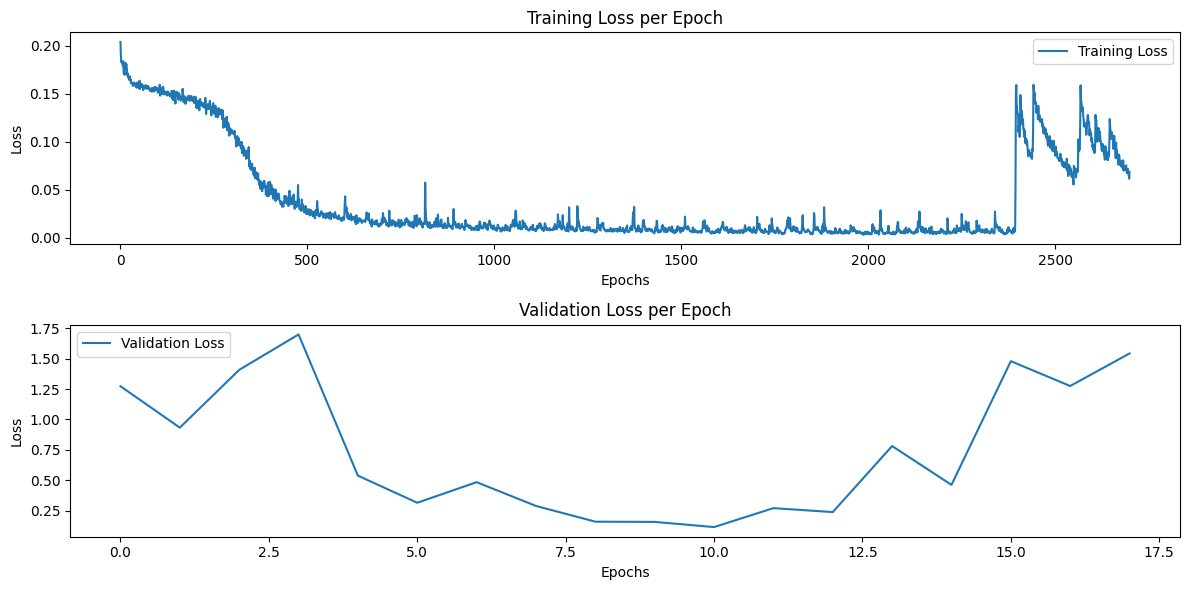

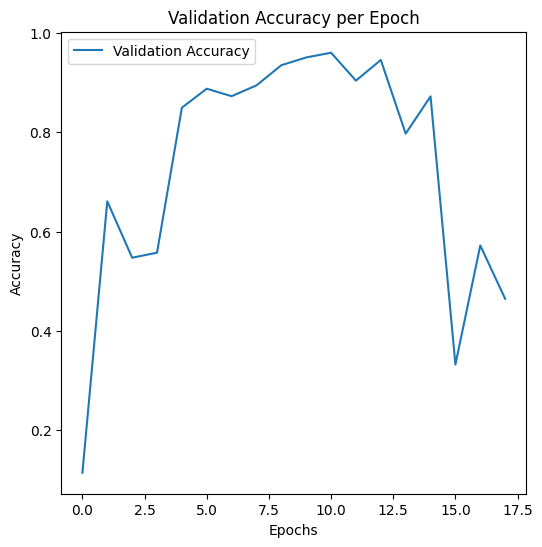

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

audio_dir = '/home/sangheon/Desktop/Pansori/Audio'
label_dir = '/home/sangheon/Desktop/Pansori_2025_ISMIR/PansoriData/label.json'

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dataset = ChromaDataset(audio_dir, label_dir)
song_files = dataset.audio_files
loo = LeaveOneOut()
model = CNNChromagram().to(device)
optimizer = optim.Adam(model.parameters(), lr=0.005)
criterion = nn.CrossEntropyLoss()

loo_losses = []
loo_accs = []
frame_accs = []
batch_size = 8

# To store the epoch-wise losses and accuracies for plotting
train_losses = []
val_losses = []
val_accuracies = []

for train_idx, test_idx in loo.split(song_files):

    for epoch in range(150):
        model.train()
        total_loss = 0

        train_X, train_y = [], []

        for idx in train_idx:
            _, _, duration, (_, _, _) = dataset[idx]
            num_segments = int(duration // 20)

            for segment in range(num_segments):
                chroma, label, duration, (filename, start, end) = dataset[idx]
                chroma = torch.tensor(chroma, dtype=torch.float32).unsqueeze(0)
                label = torch.tensor(label, dtype=torch.float32)
                train_X.append(chroma)
                train_y.append(label)

        train_X = torch.stack(train_X).to(device)
        train_y = torch.stack(train_y).to(device).argmax(dim=-1)

        for i in range(0, len(train_X), batch_size):
            batch_X = train_X[i:i+batch_size]
            batch_y = train_y[i:i+batch_size]
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            optimizer.zero_grad()
            outputs = model(batch_X)
            loss = criterion(outputs.permute(0, 2, 1), batch_y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        train_losses.append(total_loss / len(train_X))

    loo_losses.append(total_loss)

    model.eval()

    with torch.no_grad():
        val_X, val_y = [], []
        _, _, duration, (val_file, _, _) = dataset[int(test_idx[0])]
        num_segments = int(duration // 20)

        for segment in range(num_segments):
            chroma, label, duration, (filename, start, end) = dataset[int(test_idx[0])]
            chroma = torch.tensor(chroma, dtype=torch.float32).unsqueeze(0)
            label = torch.tensor(label, dtype=torch.float32)
            val_X.append(chroma)
            val_y.append(label)

        val_X = torch.stack(val_X).to(device)
        val_y = torch.stack(val_y).to(device).argmax(dim=-1)

        val_output = model(val_X)
        val_loss = criterion(val_output.permute(0, 2, 1), val_y)
        pred_probs = torch.softmax(val_output, dim = -1)
        pred_labels = torch.argmax(pred_probs, dim = -1)
        frame_accuracy = (pred_labels == val_y).float().mean(dim = 1).cpu().numpy()
        frame_accs.append(frame_accuracy)
        accuracy = frame_accuracy.mean().item()
        print(f"Val_Filename: {filename}")
        print(f"accuracy: {accuracy}")

        # Store the validation loss and accuracy for each epoch
        val_losses.append(val_loss.item())
        val_accuracies.append(accuracy)

    loo_losses.append(val_loss.item())
    loo_accs.append(accuracy)

print("\n LOO-CV Results")
print(f"Average Validation Loss: {np.mean(loo_losses):.4f}")
print(f"Average Validation Accuracy: {np.mean(loo_accs):.4f}")

plt.figure(figsize=(12, 6))

plt.subplot(2, 1, 1)
plt.plot(train_losses, label='Training Loss')
plt.title('Training Loss per Epoch')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(2, 1, 2)
plt.plot(val_losses, label='Validation Loss')
plt.title('Validation Loss per Epoch')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 6))
plt.plot(val_accuracies, label='Validation Accuracy')
plt.title('Validation Accuracy per Epoch')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

audio_dir = '/home/sangheon/Desktop/Pansori/Audio'
label_dir = '/home/sangheon/Desktop/Pansori_2025_ISMIR/PansoriData/label.json'

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dataset = ChromaDataset(audio_dir, label_dir)
song_files = dataset.audio_files
loo = LeaveOneOut()
model = CNNChromagram().to(device)
optimizer = optim.Adam(model.parameters(), lr=0.005)
criterion = nn.CrossEntropyLoss()

loo_losses = []
loo_accs = []
frame_accs = []
batch_size = 8

# To store the epoch-wise losses and accuracies for plotting
train_losses = []
val_losses = []
val_accuracies = []

for train_idx, test_idx in loo.split(song_files):

    for epoch in range(150):
        model.train()
        total_loss = 0

        train_X, train_y = [], []

        for idx in train_idx:
            _, _, duration, (_, _, _) = dataset[idx]
            num_segments = int(duration // 20)

            for segment in range(num_segments):
                chroma, label, duration, (filename, start, end) = dataset[idx]
                chroma = torch.tensor(chroma, dtype=torch.float32).unsqueeze(0)
                label = torch.tensor(label, dtype=torch.float32)
                train_X.append(chroma)
                train_y.append(label)

        train_X = torch.stack(train_X).to(device)
        train_y = torch.stack(train_y).to(device).argmax(dim=-1)

        for i in range(0, len(train_X), batch_size):
            batch_X = train_X[i:i+batch_size]
            batch_y = train_y[i:i+batch_size]
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            optimizer.zero_grad()
            outputs = model(batch_X)
            loss = criterion(outputs.permute(0, 2, 1), batch_y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        # Store the training loss for each epoch
        train_losses.append(total_loss / len(train_X))  # Average loss for the epoch

    loo_losses.append(total_loss)

    model.eval()

    with torch.no_grad():
        val_X, val_y = [], []
        _, _, duration, (val_file, _, _) = dataset[int(test_idx[0])]
        num_segments = int(duration // 20)

        for segment in range(num_segments):
            chroma, label, duration, (filename, start, end) = dataset[int(test_idx[0])]
            chroma = torch.tensor(chroma, dtype=torch.float32).unsqueeze(0)
            label = torch.tensor(label, dtype=torch.float32)
            val_X.append(chroma)
            val_y.append(label)

        val_X = torch.stack(val_X).to(device)
        val_y = torch.stack(val_y).to(device).argmax(dim=-1)

        val_output = model(val_X)
        val_loss = criterion(val_output.permute(0, 2, 1), val_y)
        pred_probs = torch.softmax(val_output, dim = -1)
        pred_labels = torch.argmax(pred_probs, dim = -1)
        frame_accuracy = (pred_labels == val_y).float().mean(dim = 1).cpu().numpy()
        frame_accs.append(frame_accuracy)
        accuracy = frame_accuracy.mean().item()
        print(f"Val_Filename: {filename}")
        print(f"accuracy: {accuracy}")

        # Store the validation loss and accuracy for each epoch
        val_losses.append(val_loss.item())
        val_accuracies.append(accuracy)

    loo_losses.append(val_loss.item())
    loo_accs.append(accuracy)

print("\n LOO-CV Results")
print(f"Average Validation Loss: {np.mean(loo_losses):.4f}")
print(f"Average Validation Accuracy: {np.mean(loo_accs):.4f}")

plt.figure(figsize=(12, 6))

plt.subplot(2, 1, 1)
plt.plot(train_losses, label='Training Loss')
plt.title('Training Loss per Epoch')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(2, 1, 2)
plt.plot(val_losses, label='Validation Loss')
plt.title('Validation Loss per Epoch')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 6))
plt.plot(val_accuracies, label='Validation Accuracy')
plt.title('Validation Accuracy per Epoch')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


# Test Script 

In [ ]:
audio_dir = '/home/sangheon/Desktop/Pansori/Audio'
label_dir = '/home/sangheon/Desktop/Pansori_2025_ISMIR/PansoriData/label.json'

dset = ChromaDataset(audio_dir, label_dir)

chroma, label, duration, (filename, start, end) = dset[18]
print(f"Filename: {filename}")
print(f"Start Frame: {start}, End Frame: {end}")
print(f"Duration {duration}")
print(f"Chroma Shape: {chroma.shape}")

plt.subplot(2, 1, 1)
plt.imshow(chroma, aspect = 'auto', origin ='lower')

#plt.imshow(dset.loaded_chromas[filename][:,start:end], aspect = 'auto', origin ='lower')

plt.subplot(2,1,2)
plt.imshow(label, aspect='auto', interpolation='None')

s_t = start*512
e_t = end*512

ipd.display(ipd.Audio(data=dset.loaded_audio[filename][s_t:e_t], rate=16000))
print(s_t/16000, e_t/16000)

Load Chroma: 100%|██████████| 18/18 [00:07<00:00,  2.32it/s]


Chroma Shape: (25, 625)
Shifted Chroma Shape: (25, 625)


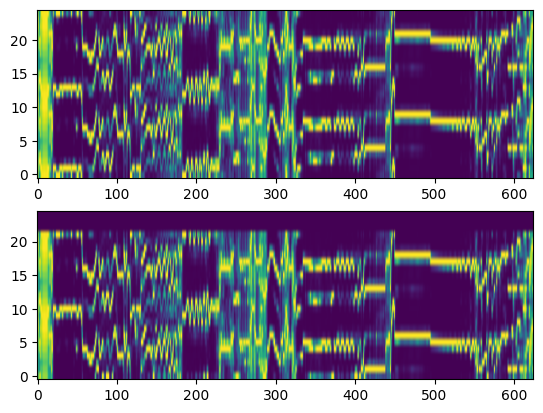

In [9]:
audio_dir = '/home/sangheon/Desktop/Pansori/Audio'
label_dir = '/home/sangheon/Desktop/Pansori_2025_ISMIR/PansoriData/label.json'

dset = ChromaDataset(audio_dir, label_dir)

chroma, label, duration, (filename, start, end) = dset[18]

plt.subplot(2, 1 ,1)
plt.imshow(chroma, aspect = 'auto', origin = 'lower')
print(f'Chroma Shape: {chroma.shape}')
shift = random.randint(-3, 3)
chroma = np.roll(chroma, shift, axis = 0)

if shift > 0:
    chroma[:shift, :] = 0
elif shift < 0:
    chroma[shift:, :] = 0
plt.subplot(2, 1, 2)
plt.imshow(chroma, aspect = 'auto', origin = 'lower')
print(f'Shifted Chroma Shape: {chroma.shape}')